In [1]:
import mplfinance as mpf
print("Import success")

Import success


SYMBOLS   : ['USDJPY']
TIMEFRAMES: ['H1']


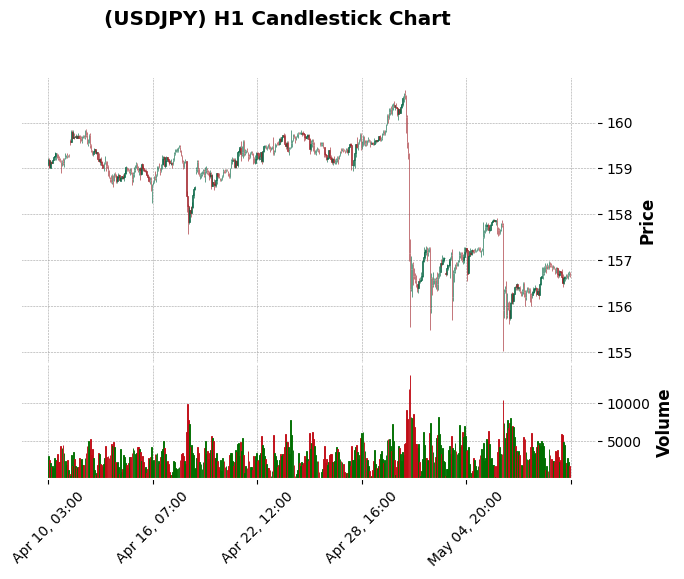

In [2]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path('./data')

# Read SYMBOLS and TIMEFRAMES from ./data/<SYMBOL>/<TIMEFRAME>/ohlcv.csv
SYMBOLS = ['USDJPY']
TIMEFRAMES = ['H1']

print('SYMBOLS   :', SYMBOLS)
print('TIMEFRAMES:', TIMEFRAMES)

MAX_BARS_TO_PLOT = 500  # keep charts responsive

for symbol in SYMBOLS:
    for timeframe in TIMEFRAMES:
        csv_path = DATA_DIR / symbol / timeframe / 'ohlcv.csv'
        if not csv_path.exists():
            continue

        bars = pd.read_csv(csv_path)

        # Normalize MT5-style lowercase columns to mplfinance format
        rename_map = {
            'open': 'Open',
            'high': 'High',
            'low': 'Low',
            'close': 'Close',
            'tick_volume': 'Volume',
        }
        bars = bars.rename(columns=rename_map)

        bars['time'] = pd.to_datetime(bars['time'], utc=True)
        bars = bars.set_index('time').sort_index()

        # mplfinance expects these exact OHLCV columns
        needed = ['Open', 'High', 'Low', 'Close', 'Volume']
        if not all(col in bars.columns for col in needed):
            print(f"Skip {symbol} {timeframe}: missing columns -> {set(needed) - set(bars.columns)}")
            continue

        plot_bars = bars[needed].tail(MAX_BARS_TO_PLOT)
        mpf.plot(
            plot_bars,
            type='candle',
            style='charles',
            title=f'({symbol}) {timeframe} Candlestick Chart',
            volume=True,
        )

In [3]:
import scipy as sp

# Support both normalized and raw OHLCV naming
high_col = 'High' if 'High' in bars.columns else 'high'
low_col = 'Low' if 'Low' in bars.columns else 'low'
close_col = 'Close' if 'Close' in bars.columns else 'close'

price_ref = float(bars[close_col].iloc[-1])
merge_tol = max(price_ref * 0.002, 1e-6)  # ~0.2% level merge tolerance

# Adaptive prominence from volatility so it works across symbols
peak_distance = 60
peak_prominence = max(float(bars[close_col].std()) * 0.35, 1e-6)

# Resistance from local highs
res_idx, _ = sp.signal.find_peaks(
    bars[high_col].values,
    distance=peak_distance,
    prominence=peak_prominence,
)
res_levels = bars.iloc[res_idx][high_col].astype(float).tolist()

# Support from local lows (peaks on inverted lows)
sup_idx, _ = sp.signal.find_peaks(
    (-bars[low_col]).values,
    distance=peak_distance,
    prominence=peak_prominence,
)
sup_levels = bars.iloc[sup_idx][low_col].astype(float).tolist()

# Add recent extremes so both sides always have anchor levels
lookback = min(252, len(bars))
res_levels.append(float(bars[high_col].iloc[-lookback:].max()))
sup_levels.append(float(bars[low_col].iloc[-lookback:].min()))


def merge_close_levels(levels: list[float], tol: float) -> list[float]:
    if not levels:
        return []
    levels = sorted(levels)
    groups = [[levels[0]]]
    for level in levels[1:]:
        if abs(level - groups[-1][-1]) <= tol:
            groups[-1].append(level)
        else:
            groups.append([level])
    return [sum(g) / len(g) for g in groups]


support_levels = merge_close_levels(sup_levels, merge_tol)
resistance_levels = merge_close_levels(res_levels, merge_tol)

print(f'Detected supports={len(support_levels)}, resistances={len(resistance_levels)}')

Detected supports=11, resistances=11


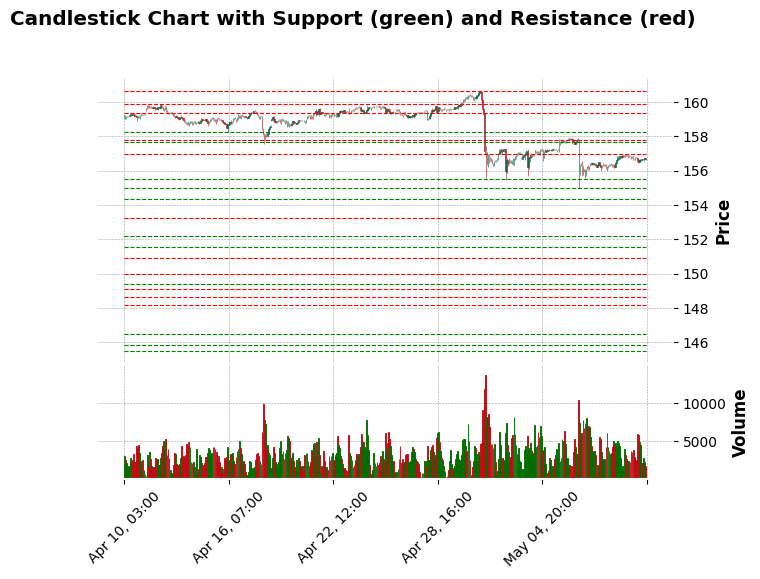

In [4]:
import numpy as np

# Use only OHLCV columns for mplfinance
plot_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
plot_cols = [c for c in plot_cols if c in bars.columns]
plot_bars = bars[plot_cols].tail(500)

# Build horizontal support/resistance overlays on plotted window
add_plot = []
for support in support_levels:
    add_plot.append(mpf.make_addplot(np.full(len(plot_bars), support), color='g', linestyle='--', width=0.8))
for resistance in resistance_levels:
    add_plot.append(mpf.make_addplot(np.full(len(plot_bars), resistance), color='r', linestyle='--', width=0.8))

mpf.plot(
    plot_bars,
    type='candle',
    style='charles',
    title='Candlestick Chart with Support (green) and Resistance (red)',
    volume=True,
    addplot=add_plot,
    warn_too_much_data=2000,
)

In [5]:
# calculate fibo

In [6]:
# Step 1) Configuration for Fibonacci + confluence with S/R
FIB_LOOKBACK = 300
SWING_WINDOW = 5  # candles left/right for local swing check
CONFLUENCE_TOL_PCT = 0.0025  # 0.25%
MIN_CONFLUENCE_SCORE = 2

print('FIB_LOOKBACK =', FIB_LOOKBACK)
print('SWING_WINDOW =', SWING_WINDOW)
print('CONFLUENCE_TOL_PCT =', CONFLUENCE_TOL_PCT)
print('MIN_CONFLUENCE_SCORE =', MIN_CONFLUENCE_SCORE)

FIB_LOOKBACK = 300
SWING_WINDOW = 5
CONFLUENCE_TOL_PCT = 0.0025
MIN_CONFLUENCE_SCORE = 2


In [7]:
# Step 2) Detect latest swing high/low and calculate Fibonacci retracement levels
high_col = 'High' if 'High' in bars.columns else 'high'
low_col = 'Low' if 'Low' in bars.columns else 'low'
close_col = 'Close' if 'Close' in bars.columns else 'close'

work = bars.tail(FIB_LOOKBACK).copy()

high_series = work[high_col]
low_series = work[low_col]

# Recent swing points using centered rolling max/min
swing_high_mask = high_series == high_series.rolling(2 * SWING_WINDOW + 1, center=True).max()
swing_low_mask = low_series == low_series.rolling(2 * SWING_WINDOW + 1, center=True).min()

swing_highs = work[swing_high_mask].dropna(subset=[high_col])
swing_lows = work[swing_low_mask].dropna(subset=[low_col])

if swing_highs.empty or swing_lows.empty:
    raise RuntimeError('Not enough swing points. Increase FIB_LOOKBACK or reduce SWING_WINDOW.')

last_swing_high = float(swing_highs[high_col].iloc[-1])
last_swing_low = float(swing_lows[low_col].iloc[-1])

# Use direction based on which swing happened later in time
trend_is_up = swing_lows.index[-1] > swing_highs.index[-1]

if trend_is_up:
    fib_high, fib_low = last_swing_high, last_swing_low
else:
    fib_high, fib_low = last_swing_high, last_swing_low

span = fib_high - fib_low
if span <= 0:
    raise RuntimeError('Invalid swing range for Fibonacci calculation.')

fib_levels = {
    '0.0': fib_high,
    '0.236': fib_high - span * 0.236,
    '0.382': fib_high - span * 0.382,
    '0.5': fib_high - span * 0.5,
    '0.618': fib_high - span * 0.618,
    '0.786': fib_high - span * 0.786,
    '1.0': fib_low,
}

print('Last swing high:', round(fib_high, 6))
print('Last swing low :', round(fib_low, 6))
print('Trend mode     :', 'pullback in uptrend' if trend_is_up else 'pullback in downtrend')
print('Fib levels:')
for k, v in fib_levels.items():
    print(f'  {k:>5} -> {v:.6f}')

Last swing high: 156.981
Last swing low : 156.421
Trend mode     : pullback in uptrend
Fib levels:
    0.0 -> 156.981000
  0.236 -> 156.848840
  0.382 -> 156.767080
    0.5 -> 156.701000
  0.618 -> 156.634920
  0.786 -> 156.540840
    1.0 -> 156.421000


In [8]:
# Step 3) Build confluence table (Fib + Support/Resistance proximity)
import pandas as pd

last_close = float(bars[close_col].iloc[-1])
price_tol = max(last_close * CONFLUENCE_TOL_PCT, 1e-6)

sr_levels = sorted(set([float(x) for x in support_levels + resistance_levels]))

rows = []
for fib_name, fib_price in fib_levels.items():
    nearby_sr = [lv for lv in sr_levels if abs(lv - fib_price) <= price_tol]
    nearest_sr = min(sr_levels, key=lambda lv: abs(lv - fib_price)) if sr_levels else None
    distance_to_price = abs(last_close - fib_price)

    score = 0
    if nearby_sr:
        score += 2
    if distance_to_price <= price_tol * 2:
        score += 1

    rows.append({
        'fib': fib_name,
        'fib_price': fib_price,
        'nearby_sr_count': len(nearby_sr),
        'nearest_sr': nearest_sr,
        'dist_to_price': distance_to_price,
        'confluence_score': score,
    })

confluence_df = pd.DataFrame(rows).sort_values(['confluence_score', 'nearby_sr_count'], ascending=False)
print('Last close:', round(last_close, 6), '| tolerance:', round(price_tol, 6))
confluence_df

Last close: 156.683 | tolerance: 0.391707


,fib,fib_price,nearby_sr_count,nearest_sr,dist_to_price,confluence_score
0,0.0,156.98100,1,156.951,0.29800,3
1,0.236,156.84884,1,156.951,0.16584,3
2,0.382,156.76708,1,156.951,0.08408,3
3,0.5,156.70100,1,156.951,0.01800,3
4,0.618,156.63492,1,156.951,0.04808,3
5,0.786,156.54084,0,156.951,0.14216,1
6,1.0,156.42100,0,156.951,0.26200,1


In [9]:
# Step 4) Trading plan candidates from strongest confluence
best = confluence_df[confluence_df['confluence_score'] >= MIN_CONFLUENCE_SCORE].copy()

if best.empty:
    print('No setup passed threshold. Reduce MIN_CONFLUENCE_SCORE or increase CONFLUENCE_TOL_PCT.')
else:
    def classify_side(row):
        return 'BUY_ZONE' if row['fib_price'] < last_close else 'SELL_ZONE'

    best['zone'] = best.apply(classify_side, axis=1)

    # Simple trade idea fields
    best['entry'] = best['fib_price']
    best['stop'] = best.apply(lambda r: r['entry'] * (0.997 if r['zone'] == 'BUY_ZONE' else 1.003), axis=1)
    best['target_1'] = best.apply(lambda r: r['entry'] * (1.004 if r['zone'] == 'BUY_ZONE' else 0.996), axis=1)
    best['target_2'] = best.apply(lambda r: r['entry'] * (1.008 if r['zone'] == 'BUY_ZONE' else 0.992), axis=1)

    cols = ['fib', 'zone', 'entry', 'stop', 'target_1', 'target_2', 'nearby_sr_count', 'confluence_score']
    display(best[cols].sort_values(['confluence_score', 'nearby_sr_count'], ascending=False))

,fib,zone,entry,stop,target_1,target_2,nearby_sr_count,confluence_score
0,0.0,SELL_ZONE,156.98100,157.451943,156.353076,155.725152,1,3
1,0.236,SELL_ZONE,156.84884,157.319387,156.221445,155.594049,1,3
2,0.382,SELL_ZONE,156.76708,157.237381,156.140012,155.512943,1,3
3,0.5,SELL_ZONE,156.70100,157.171103,156.074196,155.447392,1,3
4,0.618,BUY_ZONE,156.63492,156.165015,157.261460,157.887999,1,3


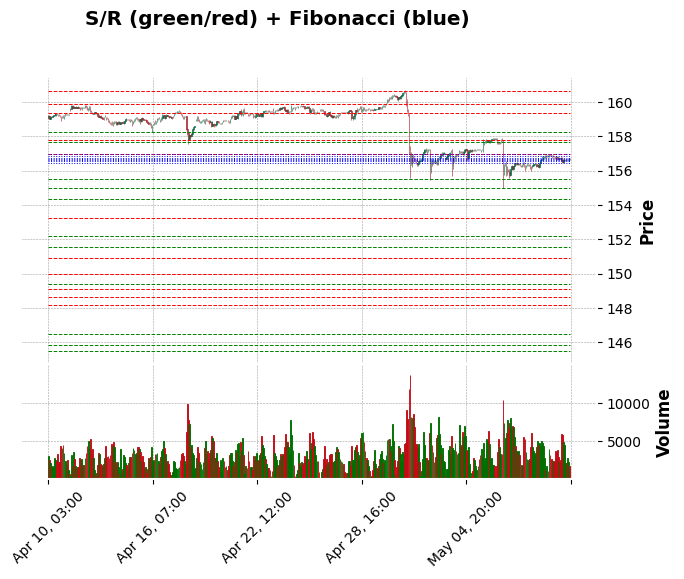

In [10]:
# Step 5) Optional visual check: overlay Fib lines + S/R lines on chart
import numpy as np

plot_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
plot_cols = [c for c in plot_cols if c in bars.columns]
plot_bars = bars[plot_cols].tail(500)

add_plot = []
for lv in support_levels:
    add_plot.append(mpf.make_addplot(np.full(len(plot_bars), lv), color='g', linestyle='--', width=0.7))
for lv in resistance_levels:
    add_plot.append(mpf.make_addplot(np.full(len(plot_bars), lv), color='r', linestyle='--', width=0.7))
for fib_name, fib_price in fib_levels.items():
    add_plot.append(mpf.make_addplot(np.full(len(plot_bars), fib_price), color='b', linestyle=':', width=0.7))

mpf.plot(
    plot_bars,
    type='candle',
    style='charles',
    title='S/R (green/red) + Fibonacci (blue)',
    volume=True,
    addplot=add_plot,
    warn_too_much_data=2000,
)

In [11]:
# Step 6) Strategy configuration (ATR risk model + confluence zones)
RISK_ATR_MULT_STOP = 1.5
RISK_ATR_MULT_TP = 3.0
ATR_PERIOD = 14
SMA_FAST = 20
SMA_SLOW = 50
ZONE_TOL_PCT = CONFLUENCE_TOL_PCT

print('ATR_PERIOD =', ATR_PERIOD)
print('RISK_ATR_MULT_STOP =', RISK_ATR_MULT_STOP)
print('RISK_ATR_MULT_TP =', RISK_ATR_MULT_TP)
print('SMA_FAST/SMA_SLOW =', SMA_FAST, '/', SMA_SLOW)

# Split confluence levels into buy/sell zone candidates
buy_zones = []
sell_zones = []
if 'best' in globals() and not best.empty:
    for _, row in best.iterrows():
        if row['zone'] == 'BUY_ZONE':
            buy_zones.append(float(row['entry']))
        else:
            sell_zones.append(float(row['entry']))

# Fallback to generic levels if no confluence candidates passed filter
if not buy_zones:
    buy_zones = [float(x) for x in support_levels[-5:]] if support_levels else []
if not sell_zones:
    sell_zones = [float(x) for x in resistance_levels[:5]] if resistance_levels else []

print('Buy zones :', [round(x, 6) for x in buy_zones])
print('Sell zones:', [round(x, 6) for x in sell_zones])

ATR_PERIOD = 14
RISK_ATR_MULT_STOP = 1.5
RISK_ATR_MULT_TP = 3.0
SMA_FAST/SMA_SLOW = 20 / 50
Buy zones : [156.63492]
Sell zones: [156.981, 156.84884, 156.76708, 156.701]


In [12]:
# Step 7) Prepare dataframe for Backtrader and build signal columns
bt_df = bars.copy().sort_index()

# Normalize required OHLCV columns for Backtrader
rename_map_bt = {
    'open': 'Open',
    'high': 'High',
    'low': 'Low',
    'close': 'Close',
    'tick_volume': 'Volume',
}
bt_df = bt_df.rename(columns=rename_map_bt)

required = ['Open', 'High', 'Low', 'Close', 'Volume']
missing = [c for c in required if c not in bt_df.columns]
if missing:
    raise RuntimeError(f'Missing Backtrader columns: {missing}')

# ATR + trend filters
prev_close = bt_df['Close'].shift(1)
tr = pd.concat([
    (bt_df['High'] - bt_df['Low']).abs(),
    (bt_df['High'] - prev_close).abs(),
    (bt_df['Low'] - prev_close).abs(),
], axis=1).max(axis=1)
bt_df['ATR'] = tr.rolling(ATR_PERIOD).mean()

bt_df['SMA_FAST'] = bt_df['Close'].rolling(SMA_FAST).mean()
bt_df['SMA_SLOW'] = bt_df['Close'].rolling(SMA_SLOW).mean()

# Zone proximity helpers
zone_tol = float(bt_df['Close'].iloc[-1]) * ZONE_TOL_PCT


def near_any_zone(price: float, zones: list[float], tol: float) -> bool:
    return any(abs(price - z) <= tol for z in zones)


bt_df['long_signal'] = bt_df.apply(
    lambda r: int(
        pd.notna(r['ATR']) and pd.notna(r['SMA_FAST']) and pd.notna(r['SMA_SLOW'])
        and r['SMA_FAST'] >= r['SMA_SLOW']
        and near_any_zone(float(r['Close']), buy_zones, zone_tol)
    ),
    axis=1,
)

bt_df['short_signal'] = bt_df.apply(
    lambda r: int(
        pd.notna(r['ATR']) and pd.notna(r['SMA_FAST']) and pd.notna(r['SMA_SLOW'])
        and r['SMA_FAST'] <= r['SMA_SLOW']
        and near_any_zone(float(r['Close']), sell_zones, zone_tol)
    ),
    axis=1,
)

bt_df[['Close', 'ATR', 'SMA_FAST', 'SMA_SLOW', 'long_signal', 'short_signal']].tail(10)

,Close,ATR,SMA_FAST,SMA_SLOW,long_signal,short_signal
time,,,,,,
2026-05-08 14:00:00+00:00,156.738,0.115714,156.79935,156.50402,1,0
2026-05-08 15:00:00+00:00,156.629,0.128929,156.79965,156.52174,1,0
2026-05-08 16:00:00+00:00,156.508,0.141571,156.79220,156.53042,1,0
2026-05-08 17:00:00+00:00,156.616,0.140429,156.78645,156.53734,1,0
2026-05-08 18:00:00+00:00,156.631,0.139929,156.77500,156.54786,1,0
2026-05-08 19:00:00+00:00,156.688,0.141500,156.76545,156.55624,1,0
2026-05-08 20:00:00+00:00,156.678,0.139714,156.75865,156.56130,1,0
2026-05-08 21:00:00+00:00,156.682,0.145500,156.74885,156.56662,1,0
2026-05-08 22:00:00+00:00,156.717,0.147214,156.74285,156.57146,1,0


In [13]:
# Step 8) Backtrader strategy definition using generated signals
try:
    import backtrader as bt
except ImportError as exc:
    raise RuntimeError('backtrader is not installed in current environment. Install with: pip install backtrader') from exc


class ConfluenceSignalData(bt.feeds.PandasData):
    lines = ('long_signal', 'short_signal', 'atr')
    params = (
        ('datetime', None),
        ('open', 'Open'),
        ('high', 'High'),
        ('low', 'Low'),
        ('close', 'Close'),
        ('volume', 'Volume'),
        ('openinterest', -1),
        ('long_signal', 'long_signal'),
        ('short_signal', 'short_signal'),
        ('atr', 'ATR'),
    )


class ConfluenceStrategy(bt.Strategy):
    params = dict(
        atr_stop_mult=RISK_ATR_MULT_STOP,
        atr_tp_mult=RISK_ATR_MULT_TP,
    )

    def __init__(self):
        self.order = None
        self.entry_price = None
        self.stop_price = None
        self.take_price = None
        self.entry_points = []  # (datetime, price, side)

    def next(self):
        if self.order:
            return

        close = float(self.data.close[0])
        atr = float(self.data.atr[0]) if self.data.atr[0] == self.data.atr[0] else None

        if atr is None or atr <= 0:
            return

        if not self.position:
            if int(self.data.long_signal[0]) == 1:
                self.entry_price = close
                self.stop_price = close - self.p.atr_stop_mult * atr
                self.take_price = close + self.p.atr_tp_mult * atr
                self.order = self.buy()
            elif int(self.data.short_signal[0]) == 1:
                self.entry_price = close
                self.stop_price = close + self.p.atr_stop_mult * atr
                self.take_price = close - self.p.atr_tp_mult * atr
                self.order = self.sell()
        else:
            if self.position.size > 0:
                if close <= self.stop_price or close >= self.take_price:
                    self.order = self.close()
            else:
                if close >= self.stop_price or close <= self.take_price:
                    self.order = self.close()

    def notify_order(self, order):
        if order.status == order.Completed and order.isbuy() and self.position.size > 0:
            dt = bt.num2date(order.executed.dt)
            self.entry_points.append((dt, float(order.executed.price), 'LONG'))
        elif order.status == order.Completed and order.issell() and self.position.size < 0:
            dt = bt.num2date(order.executed.dt)
            self.entry_points.append((dt, float(order.executed.price), 'SHORT'))

        if order.status in [order.Completed, order.Canceled, order.Margin, order.Rejected]:
            self.order = None

Backtest complete
Start Value : 10000.00
End Value   : 10007.79
PnL         : 7.79
Trades      : 33 | Won: 13 | Lost: 20 | WinRate: 39.39%
Max Drawdown: 0.18694913515622263
Sharpe      : -0.20148762454661864
Entry points captured: 34 | showing last: 20


ValueError: zero-size array to reduction operation maximum which has no identity

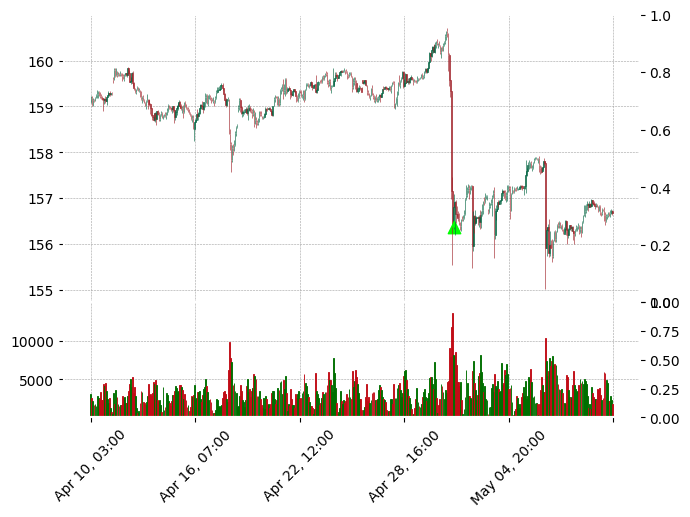

In [14]:
# Step 9) Run Backtrader backtest and show core metrics
from math import isnan

run_df = bt_df.dropna(subset=['ATR', 'SMA_FAST', 'SMA_SLOW']).copy()

if run_df.empty:
    raise RuntimeError('No rows available for backtest after indicators warm-up.')

cerebro = bt.Cerebro()
cerebro.broker.setcash(10_000.0)
cerebro.broker.setcommission(commission=0.0002)  # adjust for your broker/cfd model
cerebro.addsizer(bt.sizers.PercentSizer, percents=10)

feed = ConfluenceSignalData(dataname=run_df)
cerebro.adddata(feed)
cerebro.addstrategy(ConfluenceStrategy)

# analyzers
cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name='trades')
cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='sharpe', timeframe=bt.TimeFrame.Days)
cerebro.addanalyzer(bt.analyzers.DrawDown, _name='dd')

start_value = cerebro.broker.getvalue()
results = cerebro.run()
strat = results[0]
end_value = cerebro.broker.getvalue()

trade_analysis = strat.analyzers.trades.get_analysis()
sharpe_analysis = strat.analyzers.sharpe.get_analysis()
dd_analysis = strat.analyzers.dd.get_analysis()

total_closed = trade_analysis.get('total', {}).get('closed', 0)
won = trade_analysis.get('won', {}).get('total', 0)
lost = trade_analysis.get('lost', {}).get('total', 0)
win_rate = (won / total_closed * 100.0) if total_closed else 0.0

max_dd = dd_analysis.get('max', {}).get('drawdown', None)
sharpe = sharpe_analysis.get('sharperatio', None)

print('Backtest complete')
print(f'Start Value : {start_value:.2f}')
print(f'End Value   : {end_value:.2f}')
print(f'PnL         : {end_value - start_value:.2f}')
print(f'Trades      : {total_closed} | Won: {won} | Lost: {lost} | WinRate: {win_rate:.2f}%')
print(f'Max Drawdown: {max_dd if max_dd is not None else "N/A"}')
print(f'Sharpe      : {sharpe if sharpe is not None else "N/A"}')

# Plot last 20 executed entries on chart
entry_points = getattr(strat, 'entry_points', [])
last_entries = entry_points[-20:]
print(f'Entry points captured: {len(entry_points)} | showing last: {len(last_entries)}')

if last_entries:
    import numpy as np

    chart_df = run_df.tail(500).copy()
    marker_long = np.full(len(chart_df), np.nan)
    marker_short = np.full(len(chart_df), np.nan)

    # map executed entry timestamps into plotted window (nearest candle index)
    for dt, px, side in last_entries:
        ts = pd.Timestamp(dt)
        if ts.tzinfo is None:
            ts = ts.tz_localize('UTC')
        else:
            ts = ts.tz_convert('UTC')

        if len(chart_df.index) == 0:
            continue

        i = int(chart_df.index.get_indexer([ts], method='nearest')[0])
        if i < 0 or i >= len(chart_df):
            continue

        if side == 'LONG':
            marker_long[i] = px
        else:
            marker_short[i] = px

    add_plots = []
    if np.isfinite(marker_long).any():
        add_plots.append(mpf.make_addplot(marker_long, type='scatter', marker='^', markersize=80, color='lime'))
    if np.isfinite(marker_short).any():
        add_plots.append(mpf.make_addplot(marker_short, type='scatter', marker='v', markersize=80, color='red'))

    if add_plots:
        mpf.plot(
            chart_df[['Open', 'High', 'Low', 'Close', 'Volume']],
            type='candle',
            style='charles',
            title='Backtest - Last 20 Entry Points (^ long, v short)',
            volume=True,
            addplot=add_plots,
            warn_too_much_data=2000,
        )
    else:
        print('No entry markers inside plotted window; chart not drawn.')

In [ ]:
#show chart